In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from scipy.stats import beta


In [2]:
########################################################################################################
# (Beta Distribution)

alpha_ = 20
beta_ = 20
beta.ppf(1-0.05, alpha_, beta_) - beta.ppf(0.05, alpha_, beta_)
(beta.ppf(1-0.05, alpha_, beta_) + beta.ppf(0.05, alpha_, beta_))/2

np.float64(0.5)

In [4]:
def plot_beta_distributions(alpha_, beta_, color=None):
    x = np.linspace(0, 1, 100)
    
    # plt.figure(figsize=(8, 5))
    
    y = beta.pdf(x, alpha_, beta_)
    plt.plot(x, y, label=f'alpha={alpha_}, beta={beta_}', color=color)
    
    plt.title('Beta Distributions')
    plt.xlabel('Probability')
    plt.ylabel('Density')
    plt.legend()

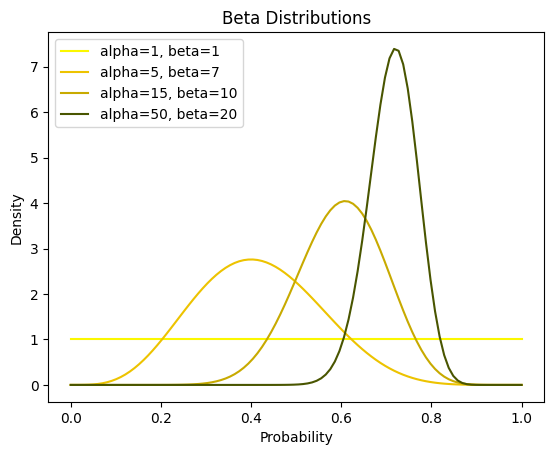

In [5]:

alpha_list = [1, 5, 15, 50]
beta_list = [1, 7, 10, 20]


for alpha_, beta_ in zip(alpha_list, beta_list):
    plot_beta_distributions(alpha_, beta_, color=(1-alpha_/70, 1-beta_/30, 0))
plt.legend(loc='upper left')
plt.show()


0


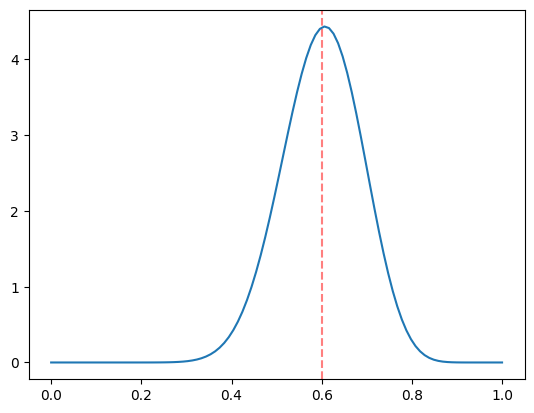

In [7]:
#######################################################################################################


from IPython.display import clear_output
import time
rng = np.random.RandomState()    


p = 0.6

alpha_ = 1e-6
beta_ = 1e-6


x = np.linspace(0, 1, 100)
for i in range(30):
    sample_p = rng.rand()
    # np.random.binomial(n=1, p=0.5)
    
    print(int(sample_p < p))
    if sample_p < p:
        alpha_ += 1
    else:
        beta_ += 1
    y = beta.pdf(x, alpha_, beta_)
    
    plt.plot(x, y, label=f'alpha={alpha_}, beta={beta_}')
    plt.axvline(p, color='red', ls='--', alpha=0.5)
    plt.show()
    clear_output(wait=True)
    time.sleep(0.1)


In [8]:
###########################################################################################################
# (Beta Distributino Class)
from scipy.stats import beta

class Beta:
    def __init__(self, a=1e-8, b=1e-8):
        self.a = a
        self.b = b
        self.beta = beta

    def add_alpha(self, inc=1):
        self.a += inc

    def add_beta(self, inc=1):
        self.b += inc

    def init_params(self, a=None, b=None):
        a = self.a if a is None else a
        b = self.b if b is None else b
        return a, b
    
    def __repr__(self):
        return f"Beta(a={self.a}, b={self.b})"

    # ----------------------------
    # sampling / density
    # ----------------------------
    # rvs : 난수 샘플 생성
    def rvs(self, a=None, b=None, loc=0, scale=1, size=1, random_state=None):
        a, b = self.init_params(a, b)
        return self.beta.rvs(a=a, b=b, loc=loc, scale=scale, size=size, random_state=random_state)

    # pdf : 특정 값의 확률밀도 [x:P(x)]
    def pdf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.pdf(x, a=a, b=b, loc=loc, scale=scale)

    def logpdf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.logpdf(x, a=a, b=b, loc=loc, scale=scale)

    # ----------------------------
    # CDF / SF / inverse
    # ----------------------------
    # cdf : 누적확률 값 [x : P(X≤x)]
    def cdf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.cdf(x, a=a, b=b, loc=loc, scale=scale)

    def logcdf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.logcdf(x, a=a, b=b, loc=loc, scale=scale)

    # sf : 생존함수 (1-CDF) [x: P(X>x)]
    def sf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.sf(x, a=a, b=b, loc=loc, scale=scale)

    def logsf(self, x, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.logsf(x, a=a, b=b, loc=loc, scale=scale)

    # ppf : 누적확률의 역함수(분위수) [P(X≤x)=q]
    def ppf(self, q, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.ppf(q, a=a, b=b, loc=loc, scale=scale)

    # sf : 생존함수의 역함수(분위수) [x: P(X>x)=q]
    def isf(self, q, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.isf(q, a=a, b=b, loc=loc, scale=scale)

    # ----------------------------
    # moments / stats
    # ----------------------------
    def moment(self, order, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.moment(order, a=a, b=b, loc=loc, scale=scale)

    def stats(self, a=None, b=None, loc=0, scale=1, moments='mv'):
        a, b = self.init_params(a, b)
        return self.beta.stats(a=a, b=b, loc=loc, scale=scale, moments=moments)

    def entropy(self, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.entropy(a=a, b=b, loc=loc, scale=scale)

    def expect(self, func, a=None, b=None, loc=0, scale=1,
               lb=None, ub=None, conditional=False, **kwds):
        a, b = self.init_params(a, b)
        # SciPy expect는 args=(a,b) 형태로 shape를 전달
        return self.beta.expect(func, args=(a, b), loc=loc, scale=scale,
                                lb=lb, ub=ub, conditional=conditional, **kwds)

    # ----------------------------
    # point estimates
    # ----------------------------
    def median(self, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.median(a=a, b=b, loc=loc, scale=scale)

    def mean(self, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.mean(a=a, b=b, loc=loc, scale=scale)

    def var(self, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.var(a=a, b=b, loc=loc, scale=scale)

    def std(self, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.std(a=a, b=b, loc=loc, scale=scale)

    def interval(self, confidence, a=None, b=None, loc=0, scale=1):
        a, b = self.init_params(a, b)
        return self.beta.interval(confidence, a=a, b=b, loc=loc, scale=scale)

    # ----------------------------
    # fit : 주어진 데이터에 가장 잘 맞는 bet분포 paameter(alpha, beta를 추정)
    #       ㄴ 대부분 loc, scale을 고정한다(이렇게 해야 진짜 alpha와 beta추정가능) 
    #          >> alpha, beta_param, _, _ = beta.fit(data, floc=0, fscale=1)
    # ----------------------------
    def fit(self, data, update=False, **kwargs):
        """
        SciPy beta.fit(data)는 (a, b, loc, scale)를 반환.
        - update=False: 추정치만 반환
        - update=True : self.a, self.b도 업데이트 (loc/scale은 별도 관리 안 함)
        """
        a_hat, b_hat, loc_hat, scale_hat = self.beta.fit(data, **kwargs)
        if update:
            self.a = a_hat
            self.b = b_hat
        return a_hat, b_hat, loc_hat, scale_hat

    # display plot
    def plot(self, a=None, b=None, num=100, figsize=None, color=None, return_plot=False):
        a = self.a if a is None else a
        b = self.b if b is None else b
        
        x = np.linspace(0, 1, num)
        
        if figsize is not None:
            fig = plt.figure(figsize=figsize)
        
        y = beta.pdf(x, a, b)
        plt.plot(x, y, label=f'a={a:.2f}, b={b:.2f}', color=color)
        
        plt.title('Beta Distributions')
        plt.xlabel('Probability')
        plt.ylabel('Density')
        plt.legend()
        
        if return_plot:
            plt.close()
            return fig


In [9]:
########################################################################################################
########################################################################################################
########################################################################################################
# (Environment Setting)
rng = np.random.RandomState(6)

def random_noise(scale=0.2):
    return rng.rand()*scale - scale/2



In [10]:
n_process = rng.randint(3,8)
n_fac_in_process = rng.randint(1, 5, size=n_process)
max_fac = max(n_fac_in_process)

In [11]:
# ---------------------------------------------------------------------------------------------------
# make position
def make_pos(n_fac_in_process):
    x_pos = [[np.nan] + [ei+1]*f  for ei, f in enumerate(n_fac_in_process)]
    y_pos = [[np.nan] + (np.arange(1, f+1)/(f+1) * (max_fac+2) + random_noise() ).tolist()  for f in n_fac_in_process]
    return x_pos, y_pos

x_pos, y_pos = make_pos(n_fac_in_process)
print(x_pos)
print(y_pos)


[[nan, 1, 1], [nan, 2, 2, 2, 2], [nan, 3], [nan, 4, 4, 4], [nan, 5, 5]]
[[nan, 1.90833932514505, 3.90833932514505], [nan, 1.1215313359871937, 2.321531335987194, 3.521531335987193, 4.721531335987194], [nan, 3.019010412841248], [nan, 1.5059634724385642, 3.005963472438564, 4.505963472438564], [nan, 1.9837614857113308, 3.983761485711331]]


In [12]:
# ---------------------------------------------------------------------------------------------------
def process_plot(n_fac_in_process, pathes=[], label=[], abnormal=[], beta_dist=None,
            box_kwargs=dict(conf=0.90, box_width=0.2, box_height=0.5, box_dx=0.1, text_fs=5) ):
    conf      = box_kwargs["conf"]
    box_width = box_kwargs["box_width"]
    box_height= box_kwargs["box_height"]
    box_dx    = box_kwargs["box_dx"]
    text_fs   = box_kwargs["text_fs"]

    # -------------------------
    x_pos, y_pos = make_pos(n_fac_in_process)

    # -------------------------
    # point
    for x_list, y_list in zip(x_pos, y_pos):
        for yi, (x, y) in enumerate(zip(x_list, y_list)):
            if not np.isnan(x):
                plt.scatter(x, y, color='gray')
                plt.text(x-0.3, y+0.1, f"x{x}_y{yi}", fontsize=8, alpha=0.7)

    # -------------------------
    # abnormal
    for (axi, ayi, p) in abnormal:
        scatter = plt.scatter(x_pos[axi-1][ayi], y_pos[axi-1][ayi], color=((p/2), 0, 0))
        scateter_color = scatter.get_facecolor()
        plt.text(x_pos[axi-1][ayi]-0.075, y_pos[axi-1][ayi]-0.1, f"{p:.2f}", fontsize=8, color=scateter_color)

    # -------------------------
    # path
    for pi, path in enumerate(pathes):
        path_pos = [(x[p], y[p]) for x, y, p in zip(x_pos, y_pos, path) if not np.isnan(x[p])]
        path_pos_T = np.array(path_pos).T
        
        try:
            if len(label) == len(pathes):
                line_color = 'red' if label[pi] > 0.5 else 'mediumseagreen'
                line, = plt.plot(*path_pos_T, alpha=max(0.1, 1/len(pathes)), color=line_color)
                plt.text(*path_pos_T[:, -1], f"MTL_{pi} ({label[pi]:.1f})", fontsize=8, color=line_color)
            else:
                line, = plt.plot(*path_pos_T, alpha=max(0.3, 1/len(pathes)))
                line_color = line.get_color()
                plt.text(*path_pos_T[:, -1], f"MTL_{pi}", fontsize=8, color=line_color)
        except:
            pass
    
    
    # -------------------------
    # beta box per point
    # beta_dist[x_index][y_index] = Beta(a,b)
    # y_index=0은 표시하지 않음
    if beta_dist is not None:
        # 네가 제시한 방식에 맞춰서 "미리 mean/lcb/ucb를 리스트로 계산"해둠
        mean_list = [[float(y.mean()) for y in x] for x in beta_dist]
        lcb_list  = [[float(y.interval(conf)[0]) for y in x] for x in beta_dist]
        ucb_list  = [[float(y.interval(conf)[1]) for y in x] for x in beta_dist]

        for xi, f in enumerate(n_fac_in_process, start=1):  # xi=1..n_process
            f = int(f)
            for yi in range(1, f+1):  # ★ y=0 제외
                # 좌표
                x0 = x_pos[xi-1][yi]
                y0 = y_pos[xi-1][yi]

                # beta_dist 길이 부족시 스킵(안전)
                if (xi-1) >= len(beta_dist) or yi >= len(beta_dist[xi-1]):
                    continue

                bobj = beta_dist[xi-1][yi]
                mean = mean_list[xi-1][yi]
                lcb  = lcb_list[xi-1][yi]
                ucb  = ucb_list[xi-1][yi]

                # a,b 표기용(가능하면 표시)
                a = getattr(bobj, "a", None)
                b = getattr(bobj, "b", None)
                if (a is None or b is None) and hasattr(bobj, "args"):
                    try:
                        a, b = bobj.args[:2]
                    except Exception:
                        pass

                # 박스 위치(포인트 오른쪽)
                bx = x0 + box_dx
                by = y0 - box_height/2

                # 박스 테두리
                rect = Rectangle((bx, by), box_width, box_height, fill=False, linewidth=0.6, alpha=0.8)
                plt.gca().add_patch(rect)

                # 0~1 스케일 표시
                plt.text(bx - 0.03, by, "0", fontsize=text_fs, ha='right', va='center', alpha=0.8)
                plt.text(bx - 0.03, by + box_height, "1", fontsize=text_fs, ha='right', va='center', alpha=0.8)

                # 값 -> 박스 y좌표 변환 (클램프)
                def v_to_y(v):
                    v = 0.0 if v < 0 else (1.0 if v > 1 else v)
                    return by + v * box_height

                y_l = v_to_y(lcb)
                y_m = v_to_y(mean)
                y_u = v_to_y(ucb)

                # L/M/U 가로선 표시
                plt.plot([bx, bx + box_width], [y_l, y_l], color='mediumseagreen' , linewidth=0.6, alpha=0.9)
                plt.plot([bx, bx + box_width], [y_m, y_m], color='coral', linewidth=0.9, alpha=0.9)
                plt.plot([bx, bx + box_width], [y_u, y_u], color='steelblue' , linewidth=0.6, alpha=0.9)

                # 텍스트 표시(fontsize=5)
                plt.text(bx + box_width + 0.02, y_u, f"U {ucb:.2f}", fontsize=text_fs, va='center')
                plt.text(bx + box_width + 0.02, y_m, f"M {mean:.2f}", fontsize=text_fs, va='center')
                plt.text(bx + box_width + 0.02, y_l, f"L {lcb:.2f}", fontsize=text_fs, va='center')

                # (a,b) 박스 위 표시
                if a is not None and b is not None:
                    plt.text(
                        bx + box_width/2, by + box_height + 0.03,
                        f"a={float(a):.0f}, b={float(b):.0f}",
                        fontsize=text_fs, ha='center', va='bottom', alpha=0.85
                    )

    plt.xlim(0.5, len(n_fac_in_process)+1)

# process_plot(n_fac_in_process)
# plt.show()

[[1 4 0 0 1]
 [0 2 0 0 2]
 [1 2 1 1 2]]


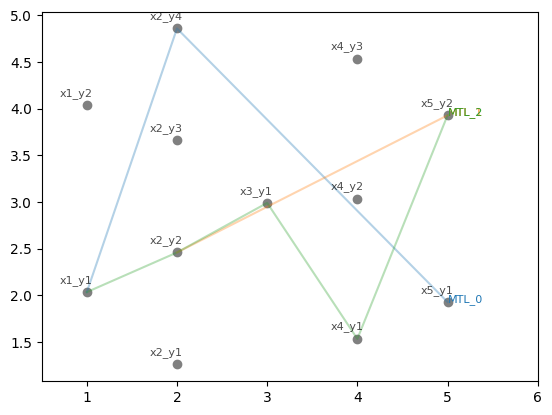

In [13]:
# ---------------------------------------------------------------------------------------------------
# generate random path
def random_path_generator(n=1):
    return np.stack([[int(rng.choice(np.arange(f+1))) for f in n_fac_in_process] for _ in range(n)])

random_paths = random_path_generator(n=3)
print(random_paths)
# process_plot(n_fac_in_process, random_paths)


process_plot(n_fac_in_process, random_paths)
plt.show()

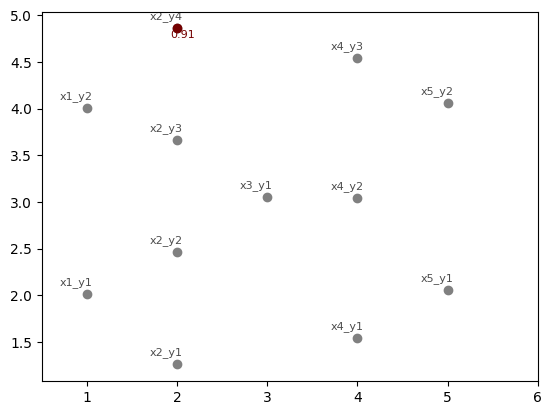

In [16]:

###################################################################################################
abnormal_p = 0.7
# ---------------------------------------------------------------------------------------------------
# # random label generate
# label = (rng.random( (len(X_random_paths),1) ) > abnormal_p).astype(int)
# print(label.flatten())


# designated label generate
def generate_abnormal_xy(n_fac_in_process, n=1):
    abnormal_ps = np.round((rng.random(size=n) /2 + 0.5), 2)
    abnormal_xyp = []
    for i, p in zip(range(n), abnormal_ps):
        abnormal_idx = rng.rand() * sum(n_fac_in_process)
        abnormal_x = np.where(np.cumsum(n_fac_in_process) > abnormal_idx)[0][0]+1
        abnormal_y = (n_fac_in_process - (np.cumsum(n_fac_in_process) - abnormal_idx)).astype(int)[abnormal_x-1]+1
        abnormal_xyp.append( (abnormal_x, abnormal_y, p))
    return abnormal_xyp

abnormal_xyp = generate_abnormal_xy(n_fac_in_process, n=1)
process_plot(n_fac_in_process, abnormal=abnormal_xyp)
plt.show()
# ---------------------------------------------------------------------------------------------------



In [17]:
# ★ random path generate
X_random_paths = random_path_generator(n=100)
print(X_random_paths)
# ---------------------------------------------------------------------------------------------------

[[1 3 1 0 0]
 [2 3 1 0 0]
 [1 4 0 0 1]
 [1 3 0 1 1]
 [0 0 1 2 0]
 [1 1 1 3 2]
 [2 1 1 0 2]
 [0 1 0 3 2]
 [1 4 1 0 0]
 [2 2 0 2 0]
 [2 2 1 1 2]
 [0 2 1 3 2]
 [0 4 1 2 2]
 [0 4 0 1 0]
 [1 3 1 1 0]
 [2 0 1 0 1]
 [0 0 0 0 1]
 [0 0 1 1 2]
 [1 0 0 2 2]
 [2 0 1 3 1]
 [2 1 0 1 1]
 [2 3 1 3 1]
 [0 3 0 1 1]
 [0 0 1 0 1]
 [0 3 1 3 1]
 [2 4 1 2 0]
 [1 1 0 0 2]
 [2 3 0 1 2]
 [0 0 1 0 2]
 [0 1 0 1 2]
 [1 4 0 1 1]
 [1 4 1 0 1]
 [2 1 1 1 2]
 [0 2 0 0 2]
 [2 2 0 1 2]
 [0 2 1 2 0]
 [2 2 0 1 0]
 [0 3 0 2 2]
 [0 1 1 1 2]
 [0 2 0 2 0]
 [2 3 1 1 2]
 [0 0 1 1 2]
 [2 1 1 3 1]
 [2 2 0 1 1]
 [1 4 1 1 2]
 [2 3 0 2 2]
 [0 1 1 3 0]
 [2 4 1 2 0]
 [1 1 1 3 0]
 [0 4 0 3 2]
 [0 0 1 0 0]
 [2 2 0 2 1]
 [2 2 1 2 0]
 [2 1 1 2 0]
 [1 0 1 2 0]
 [1 2 0 2 2]
 [1 2 1 3 2]
 [1 1 0 1 0]
 [0 3 0 0 0]
 [2 1 0 2 0]
 [1 2 0 0 1]
 [1 3 1 3 2]
 [2 2 1 0 1]
 [1 3 1 0 2]
 [0 3 0 3 2]
 [1 3 0 3 1]
 [2 1 0 1 0]
 [0 2 0 0 0]
 [0 3 0 1 2]
 [0 4 1 0 2]
 [0 2 1 1 1]
 [0 4 1 3 1]
 [0 1 1 3 2]
 [2 4 1 0 1]
 [2 2 1 1 2]
 [2 0 1 1 1]
 [2 0 0 3 2]

In [18]:
def generate_path_probs_and_labels(
    random_paths: np.ndarray,
    n_fac_in_process: np.ndarray,
    abnormal_xyp: list,   # [(abnormal_x, abnormal_y, p0), ...]
    base_abnormal_p: float = 0.03,
    scale: float = 100.0
):
    """
    Returns
    -------
    p_path : (N,) float
        path별 샘플링된 불량확률
    y      : (N,) int
        0=양호, 1=불량
    """
    yp_true = []
    yp_obs = []

    # 안전장치: abnormal_xyp가 공정/시설 범위 밖이면 에러 대신 무시하고 싶다면 continue로 바꿔도 됨
    for i, path in enumerate(random_paths):
        p_total = base_abnormal_p
        for (ax, ay, p0) in abnormal_xyp:
            if not (1 <= ax <= len(n_fac_in_process)):
                raise ValueError(f"abnormal_x={ax} is out of range (1..{len(n_fac_in_process)})")
            if not (1 <= ay <= n_fac_in_process[ax-1]):
                raise ValueError(f"abnormal_y={ay} is out of range (1..{n_fac_in_process[ax-1]}) for process {ax}")

            if int(path[ax-1]) == int(ay):
                p_total = float(1 - (1-p0)* (1-p_total))
        
        yp_sample = rng.beta(p_total*scale, (1-p_total)*scale)
        
        yp_true.append(p_total)
        yp_obs.append(yp_sample)

    return np.array(yp_true), np.array(yp_obs)

In [19]:
yp_true, yp_obs = generate_path_probs_and_labels(X_random_paths, n_fac_in_process, abnormal_xyp)

print(yp_true)
print(yp_obs)

[0.03   0.03   0.9127 0.03   0.03   0.03   0.03   0.03   0.9127 0.03
 0.03   0.03   0.9127 0.9127 0.03   0.03   0.03   0.03   0.03   0.03
 0.03   0.03   0.03   0.03   0.03   0.9127 0.03   0.03   0.03   0.03
 0.9127 0.9127 0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03
 0.03   0.03   0.03   0.03   0.9127 0.03   0.03   0.9127 0.03   0.9127
 0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03
 0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.9127
 0.03   0.9127 0.03   0.9127 0.03   0.03   0.03   0.03   0.9127 0.03
 0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.9127 0.03
 0.9127 0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03   0.03  ]
[0.01744517 0.01992342 0.91604718 0.015969   0.03467027 0.10324079
 0.03349238 0.02138803 0.91055625 0.03514871 0.03236618 0.04965798
 0.94875365 0.93075906 0.03583511 0.03766633 0.04950739 0.02984493
 0.00352532 0.01423831 0.07627968 0.02421698 0.0285052  0.02583829
 0.02181598 0.91382204 0.03621197 0

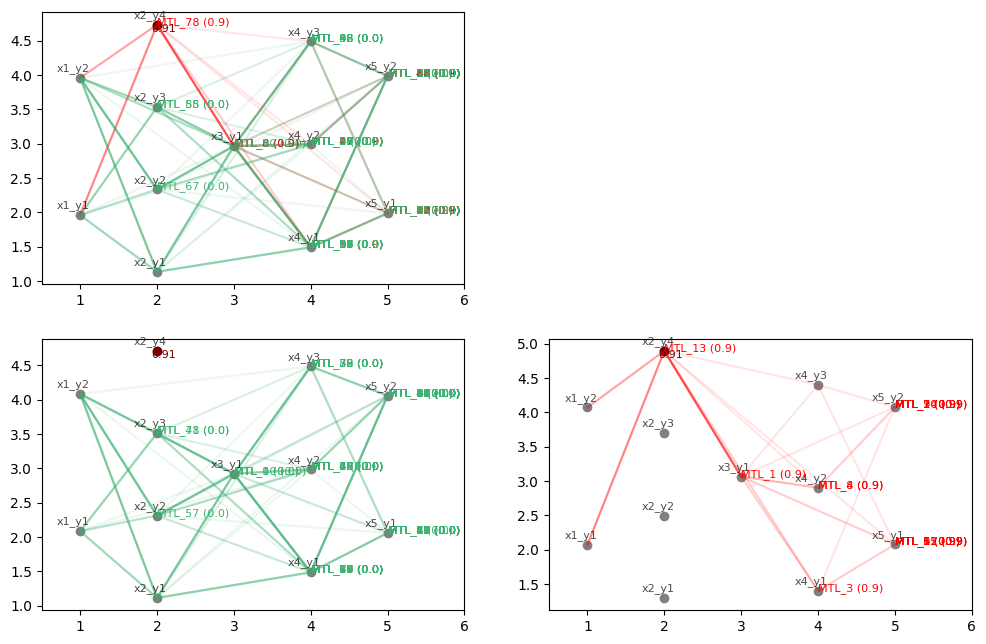

In [20]:
# -------------------------------------------------------------------------------------------
# total path
plt.figure(figsize=(12,12))
plt.subplot(3,2,1)
process_plot(n_fac_in_process, X_random_paths, label=yp_true, abnormal=abnormal_xyp)

# normal vs. abnormal path
plt.subplot(3,2,3)
process_plot(n_fac_in_process, X_random_paths[yp_true < 0.5], label=yp_true[yp_true < 0.5], abnormal=abnormal_xyp)
plt.subplot(3,2,4)
process_plot(n_fac_in_process, X_random_paths[yp_true > 0.5], label=yp_true[yp_true > 0.5], abnormal=abnormal_xyp)

# # normal vs. abnormal path
# plt.subplot(3,2,5)
# process_plot(n_fac_in_process, X_random_paths[yp_obs < 0.5], label=yp_true[yp_true < 0.5], abnormal=abnormal_xyp)
# plt.subplot(3,2,6)
# process_plot(n_fac_in_process, X_random_paths[yp_obs > 0.5], label=yp_true[yp_true > 0.5], abnormal=abnormal_xyp)
# plt.show()
plt.show()


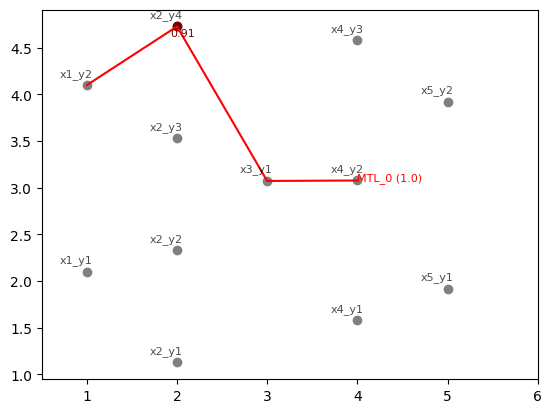

In [21]:
# -------------------------------------------------------------------------------------------
# ★ y_observation (0/1)
y_obs = rng.binomial(1, yp_obs)



# visualize
idx = rng.randint(len(X_random_paths))
process_plot(n_fac_in_process, X_random_paths[[idx]], label=y_obs[[idx]], abnormal=abnormal_xyp)


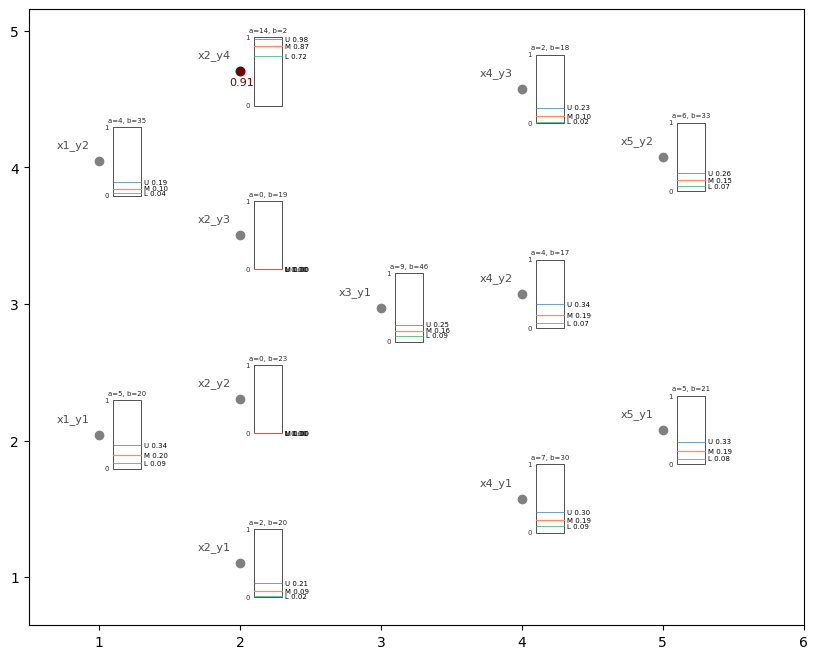

In [22]:
###########################################################################################################
# Learning
epsilon = 1e-8
process_param_alpha = [np.bincount(xg, minlength=n_fac_in_process[i]+1)+epsilon for i, xg in enumerate(X_random_paths[np.where(y_obs==1)[0]].T)]
process_param_beta = [np.bincount(xg, minlength=n_fac_in_process[i]+1)+epsilon for i, xg in enumerate(X_random_paths[np.where(y_obs==0)[0]].T)]

# beta distributions for each process
process_beta_dist = []
for x_alpha_, x_beta_ in zip(process_param_alpha, process_param_beta):
    beta_dist = [Beta(alpha_, beta_) for alpha_, beta_ in zip(x_alpha_, x_beta_)]
    process_beta_dist.append(beta_dist)


# [[y.mean() for y in x] for x in process_beta_dist]      # mean
# [[float(y.interval(0.90)[0]) > 0.5 for y in x] for x in process_beta_dist]    # lcb
# [[float(y.interval(0.90)[1]) < 0.5 for y in x] for x in process_beta_dist]    # ucb


plt.figure(figsize=(10,8))
process_plot(n_fac_in_process,  label=y_obs[[idx]], abnormal=abnormal_xyp, beta_dist=process_beta_dist)
plt.show()


In [23]:
# ---------------------------------------------------------------------------------------------------
def node_to_edge(paths):
    path_exapnd_nodes = np.concatenate([np.arange(1, paths.shape[-1]+1)[None,...,None].repeat(paths.shape[0], axis=0), 
                    paths[...,None]], axis=-1)
    path_nodes =  np.stack([np.concatenate([trajectory[trajectory[:, 1] != 0], trajectory[trajectory[:, 1] == 0]], axis=0) for trajectory in path_exapnd_nodes])
    paths_shifted = np.roll(path_nodes, shift=-1, axis=1)
    paths_edges = np.stack([path_nodes[...,:-1,:], paths_shifted[...,:-1,:]], axis=-2)
    return paths_edges


X_random_edges = node_to_edge(X_random_paths)               # (B, F, Es, Et)
X_random_edges_expand = X_random_edges.reshape(-1, 2, 2)    # (B*F, Es, Et)
X_random_edges_expand_filter = X_random_edges_expand[X_random_edges_expand[:,-1,-1] != 0]

edges, count = np.unique(X_random_edges_expand_filter, axis=0, return_counts=True)
n_count_edges = list(zip(edges, count))


In [24]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection

def gradient_lineplot(x, y, color=['steelblue', 'steelblue'], alpha=1.0, linewidth=None, ls='-', dpi=30, ax=None):
    """
    x, y 좌표를 따라 여러 색상으로 그라데이션 선을 그립니다.
    색상 변화는 실제 선의 길이에 비례합니다.
    """
    x = np.array(x)
    y = np.array(y)
    
    # 좌표 세분화
    x_fine = []
    y_fine = []
    for i in range(len(x)-1):
        x_fine.extend(np.linspace(x[i], x[i+1], dpi, endpoint=False))
        y_fine.extend(np.linspace(y[i], y[i+1], dpi, endpoint=False))
    x_fine.append(x[-1])
    y_fine.append(y[-1])
    
    x_fine = np.array(x_fine)
    y_fine = np.array(y_fine)
    
    # n개의 색상으로 colormap 생성
    cmap = LinearSegmentedColormap.from_list("custom_gradient", list(color))
    
    # 색상 값: 선의 실제 길이에 비례
    distance = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
    cumdist = np.insert(np.cumsum(distance), 0, 0)
    t = cumdist / cumdist[-1]  # 0~1 범위로 정규화
    
    colors = cmap(t)
    colors[:, -1] = alpha  # alpha 적용

    # segment 생성
    points = np.array([x_fine, y_fine]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    # LineCollection 생성
    lc = LineCollection(segments, colors=colors[:-1], linewidth=linewidth, linestyles=ls)
    
    # ax 지정 (없으면 현재 활성 Axes 사용)
    if ax is None:
        ax = plt.gca()
    ax.add_collection(lc)
    
    ax.autoscale()  # 또는 ax.autoscale_view()
    return lc

# x = np.linspace(0,20,500)
# gradient_lineplot(x, np.sin(x), color=[(1,1,1), (0.5,0.5,0.5)], linewidth=np.sqrt(100))

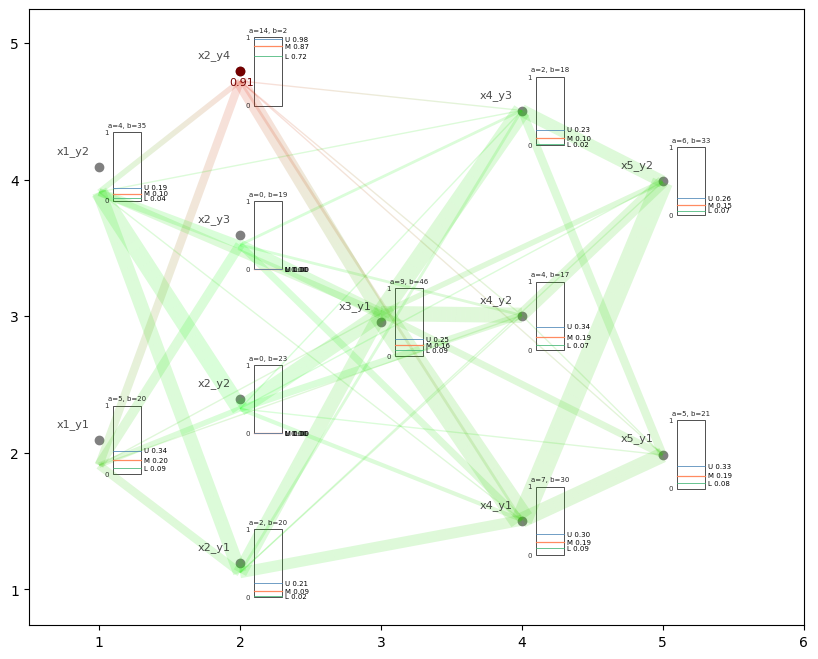

In [25]:
# Learning Plot
plt.figure(figsize=(10,8))
# [[b.mean() for b in bb]for bb in process_beta_dist]
for (es, et), w in n_count_edges:
    x_edge = x_pos[es[0]-1][es[1]], x_pos[et[0]-1][et[1]]
    y_edge = y_pos[es[0]-1][es[1]], y_pos[et[0]-1][et[1]]
    bs_edge, bt_edge = process_beta_dist[es[0]-1][es[1]].mean(), process_beta_dist[et[0]-1][et[1]].mean()

    gradient_lineplot(x_edge, y_edge, linewidth=min(30, w), color=[(bs_edge,1-bs_edge,0), (bt_edge, 1-bt_edge, 0)], alpha=0.15)
process_plot(n_fac_in_process,  label=y_obs[[idx]], abnormal=abnormal_xyp, beta_dist=process_beta_dist)
plt.show()